
### This notebook was designed to analyze data for SkinAI Experiments.

### Instructions for Use:
1. Open the script in your Python environment (e.g., VS Code, Jupyter Notebook).
2. Make sure you installed all the required libraries (listed in the first cell) in your custom environment.
3. Specify the path for the data, currently at *./CollectedData/Approved* and put the data in the ./data in the path 
4. In case you use python virtual environments you can create one first like so:
    ```
    python -m venv myenv
    ```
    activate it:

    ```
    ./myenv/Scripts/activate.bat
    ```

    and install the packages like so:

    ```
    pip install -r requirements.txt
    ```
5. Run the script. It will automatically process all the participant files in the data folder, apply the necessary functions, and save the results in the analysis folder.

### What it does:
1. Creates Directories for Saving Results
The script creates a folder where the analysis results will be saved. If this folder already exists, the script will let you know. Otherwise, it will create it.
2. Read and Process Data for Each Participant
The script goes into a folder where the data files are stored, finds all subfolders (one per participant), and processes the files in each folder.
3. For each participant:
- The script reads a data file that ends with *_record.csv* and first detectes fixations or *_record_extra.csv*, which already contains fixations.
- It filters the data to only include rows where the event named target_on occurred.
- It adds additional information to the data, such as padding (which defines the space around areas of interest), the participant ID, and the dimensions of images used in the experiment.
4. The script adds details about images shown during the experiment, such as their paths, coordinates, and bounding boxes (which define areas of interest on the screen).
Each image shown to participants is identified as either "left" or "right."
5. Run Data Processing
- plot2d(): Plots a scatter plot of the raw and fixation data for each condition. It has an option of plotting the stimuli images, they need to be in a folder specified in the dataframe.
- getFixationLatency(): Determines when each fixation started relative to the target event
- handle_carryover_fixations_and_merge(): Sometimes fixations start before or end after the event of interest. This fixes the fixation latency for these cases.
- addAOI(): Assigns fixations to the predefined Areas of Interest
- Combine Processed Data
Once the data for each participant is processed, it is added to a list.
After processing all participants, the script combines the data into a single file (fixation report) and saves it as *allSubjects_ASDViewing.csv* in the **/analysis** folder.
6. Output and Save
If any data was processed, the script combines it and saves it to a file. You will see a message indicating where the file was saved.
If no data was processed, the script will print a message saying "No data was processed."


### The notebook returns in /analysis folder
1. Plots of all trials
2. Fixation dataframe for all subject
3. Dataframe with Social indices calculated

### Adjusting the AOIs (bounding boxes) 
1. By default the AOIs are the image dimensions
2. By using a $padding$ variable you can expand the AOIs on each side. This will also have an effect on plotting.

### Important Columns
1. $user\_pred\_px\_x, user\_pred\_px\_y$: raw gaze coordinates
1. $FixXPos, FixYPos$: x,y position of fixations
2. $FixStartEnd$: indicates wheter fixation was carried over the event boundaries or not
3. $DistFromPrevFix$: distance from previous fixation in px (handy variable)
4. $PrevFixSampTime$: timestamp of the previous fixation (handy variable)
5. $PrevFixXPos, PrevFixYPos$: x,y position of preceeding fixation (handy variable)
8. $FixLatency$: the latency of fixation relative to when the target was presented
9. $FixationOrder$: the order of fixation during the event
10. $FixDur$: the duration of fixation
11. $AOI\_bbox$: the number of the bounding box where fixation landed or None
12. $AOI\_stim$: which stimulus fixation landed
13. $event$: the event during which the data is analyzed, usually *target_on* 
14. $targSampTime$: timestamp of when the target was presented

In [6]:
import os
import pandas as pd
import numpy as np

# import DeepEye analysis functions
from deepeye_analysis_package.preprocessing import getFixationLatency, handle_carryover_fixations_and_merge, addAOI
from deepeye_analysis_package.plotting import plot2d
from deepeye_analysis_package.getFixations import extract_fixations

### Set the main path

In [2]:
# path = './CollectedData/Approved'
# path = r'C:/Users/aby600/Dropbox/Appliedwork/CognitiveSolutions/Projects/DeepEye/TechnicalReports/TechnicalReport1/Test_ASDViewing/ASD/Approved'
# path = r'D:/Dropbox/Appliedwork/CognitiveSolutions/Projects/DeepEye/TechnicalReports/TechnicalReport1/Test_ASDViewing/ASD/Approved'
path = r'C:/Users/artem/Dropbox/Appliedwork/CognitiveSolutions/Projects/DeepEye/TechnicalReports/TechnicalReport1/Test_SkinAI/Approved'


### Main part

Directory 'C:/Users/artem/Dropbox/Appliedwork/CognitiveSolutions/Projects/DeepEye/TechnicalReports/TechnicalReport1/Test_SkinAI/Approved\analysis' already exists.
Processing participant 2025_07_16_11_34_53...


KeyError: 'ai_Output'

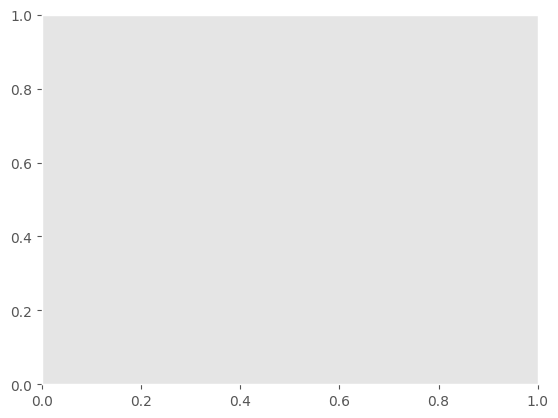

In [ ]:
# Define the AOI padding in pixels
PADDING = 0  # padding of AOI on each side, used in plot2d() and addAOI()

# Helper function to create a directory if it doesn't exist
def create_directory_if_not_exists(directory_path):
    if not os.path.exists(directory_path):
        os.makedirs(directory_path)
        print(f"Directory '{directory_path}' was created.")
    else:
        print(f"Directory '{directory_path}' already exists.")

# Define data analysis directories and create them if they don't exist yet
path_to_data = os.path.join(path, 'data')
path_to_analysis = os.path.join(path, 'analysis')
create_directory_if_not_exists(path_to_analysis)

# Initialize an empty list to hold the processed dataframes
output_dfs = []

# Get all folder names from the data directory
folder_names = [name for name in os.listdir(path_to_data) if os.path.isdir(os.path.join(path_to_data, name))]

# Process each participant's data
for fn in folder_names:
    # Check if _record_extra.csv exists, if not use _record.csv
    path_to_file = os.path.join(path_to_data, fn, f'{fn}_record_extra.csv')
    if not os.path.exists(path_to_file):
        path_to_file = os.path.join(path_to_data, fn, f'{fn}_record.csv')

        print(f'Extracting fixations for participant {fn}...')

        try:
            df = pd.read_csv(path_to_file, on_bad_lines='skip')
            df = extract_fixations(df, path_to_file)
            df = df.drop_duplicates(subset=['user_pred_px_x', 'user_pred_px_y'], ignore_index=True)  # Ensure unique coordinates (sometimes webcam is stuck)

        except FileNotFoundError:
            print(f'File does not exist: {path_to_file}')
            continue    
    else: 
        try:
            df = pd.read_csv(path_to_file, on_bad_lines='skip')
            df = df.drop_duplicates(subset=['user_pred_px_x', 'user_pred_px_y'], ignore_index=True)  # Ensure unique coordinates (sometimes webcam is stuck)

        except FileNotFoundError:
            print(f'File does not exist: {path_to_file}')
            continue

    print(f'Processing participant {fn}...')

    # Filter data to only include rows where the target was presented
    df1 = df[df['event'] == 'target_on'].copy()

    # Add padding, subject ID, and image dimensions to the dataframe
    df1['padding'] = PADDING
    df1['deepeye_id'] = fn
    df1['imageDims'] = [(500, 500)] * len(df1)

    ### Convert critical columns to numeric values if they are not ###
    df1['X'] = pd.to_numeric(df1['X'], errors='coerce')   
    df1['Y'] = pd.to_numeric(df1['Y'], errors='coerce')
    df1['FixXPos'] = pd.to_numeric(df1['FixXPos'], errors='coerce')
    df1['FixYPos'] = pd.to_numeric(df1['FixYPos'], errors='coerce')    
    df1['resX'] = pd.to_numeric(df1['resX'], errors='coerce')
    df1['resY'] = pd.to_numeric(df1['resY'], errors='coerce')
    df1['scrW_cm'] = pd.to_numeric(df1['scrW_cm'], errors='coerce')
    df1['PrevFixXPos'] = pd.to_numeric(df1['PrevFixXPos'], errors='coerce')
    df1['PrevFixYPos'] = pd.to_numeric(df1['PrevFixYPos'], errors='coerce')
    df1['PrevFixSampTime'] = pd.to_numeric(df1['PrevFixSampTime'], errors='coerce')
    df1['DistFromPrevFix'] = pd.to_numeric(df1['DistFromPrevFix'], errors='coerce')

   # Add image paths and coordinates to the dataframe
    df1['image_paths'] = df1['imageName'].apply(lambda name: [ name[1:] if name.startswith('/') else name ]) ## Remove the first slash character if present    
        
    df1['image_coords'] = df1.apply(lambda row: [
        (row.X, row.Y, row.imageDims[0], row.imageDims[1])        
    ], axis=1)

    # Add bounding boxes and their names to the dataframe
    def create_bboxes(row):
        import ast
        bboxes = [[row.X, row.Y, row.imageDims[0], row.imageDims[1]]]  # center bbox
        
        # Add AI box if it exists
        if pd.notna(row.get('AIBoxCoord')) and row.AIBoxCoord:
            # Parse string to dictionary if needed
            if isinstance(row.AIBoxCoord, str):
                ai_box = ast.literal_eval(row.AIBoxCoord)
            else:
                ai_box = row.AIBoxCoord
            bboxes.append([ai_box['x'], ai_box['y'], ai_box['width'], ai_box['height']])
        
        # Add slider box if it exists
        if pd.notna(row.get('sliderBoxCoord')) and row.sliderBoxCoord:
            # Parse string to dictionary if needed
            if isinstance(row.sliderBoxCoord, str):
                slider_box = ast.literal_eval(row.sliderBoxCoord)
            else:
                slider_box = row.sliderBoxCoord
            bboxes.append([slider_box['x'], slider_box['y'], slider_box['width'], slider_box['height']])
        
        return bboxes
    
    def create_bbox_names(row):
        names = ['center']
        
        # Add AI box name if it exists
        if pd.notna(row.get('AIBoxCoord')) and row.AIBoxCoord:
            names.append('AI_box')
        
        # Add slider box name if it exists
        if pd.notna(row.get('sliderBoxCoord')) and row.sliderBoxCoord:
            names.append('slider_box')
        
        return names
    
    df1['bboxes'] = df1.apply(create_bboxes, axis=1)
    df1['bboxesNames'] = df1.apply(create_bbox_names, axis=1)


    # Plot 2D fixations without saving the plot
    plot2d(df1, fn, path_to_analysis, condition=['diagnose', 'aiOutput'], save=True)

    # Process the data by applying preprocessing steps
    df1 = getFixationLatency(df1)
    df1 = handle_carryover_fixations_and_merge(df1, max_event_duration=10000)
    df1 = addAOI(df1)

    # Accumulate the processed dataframe for this participant
    output_dfs.append(df1)

# Concatenate all participants' data into one DataFrame
if output_dfs:
    output_df = pd.concat(output_dfs, ignore_index=True)
    output_file = os.path.join(path_to_analysis, 'allSubjects_SkinAI.csv')
    output_df.to_csv(output_file, index=False)
    print(f'Combined data saved to {output_file}')
else:
    print('No data was processed.')
